In [53]:
import valenspy

import seaborn as sns
import xarray as xr
import matplotlib.pyplot as plt
from xclim.indicators.atmos import cooling_degree_days

variables = ["pr","tas", "tasmax", "tasmin"]
period=["1980","2020"]
frequency=["day","daily"]

xarray_open_kwargs = {
    "chunks": "auto",
    "decode_coords": "all"
}

In [35]:
#Creating the input manager and adding our personal yml file to the catalog
m = valenspy.InputManager("hortense")

/dodrio/scratch/projects/2022_200/project_output/RMIB-UGent/vsc46032_kobe/ValEnsPy/src/valenspy/input/esm_catalog_builder.py:117: UserWarning: Dataset MAR is missing the required identifier 'variable_id' for filtering in its pattern or metadata.
  warnings.warn(f"Dataset {dataset_name} is missing the required identifier '{identifier}' for filtering in its pattern or metadata.")


There are files that were skipped during the catalog creation. Please check the skipped_files property for a list of skipped files.


In [36]:
path_to_yml = "/dodrio/scratch/projects/2022_200/project_output/RMIB-UGent/vsc46032_kobe/ValEnsPy/src/valenspy/ancilliary_data/cordexbeII_dataset"
m.update_catalog_from_yaml(path_to_yml)

/dodrio/scratch/projects/2022_200/project_output/RMIB-UGent/vsc46032_kobe/ValEnsPy/src/valenspy/input/esm_catalog_builder.py:117: UserWarning: Dataset MAR is missing the required identifier 'variable_id' for filtering in its pattern or metadata.
  warnings.warn(f"Dataset {dataset_name} is missing the required identifier '{identifier}' for filtering in its pattern or metadata.")


In [37]:
[file for file in m.skipped_files["CCLM"] if "daily" in file and "T_2M" in file]

['/dodrio/scratch/projects/2022_200/project_output/rcs/CORDEXBE2/postprocessing/CB2_CCLM_EUR11_EC-Earth_test/T_2M/daily/T_2M_daily_mean_1995.nc',
 '/dodrio/scratch/projects/2022_200/project_output/rcs/CORDEXBE2/postprocessing/test_experiments/EUR11_1993_NU_TT_EC_TSO/T_2M/daily/T_2M_daymax.nc',
 '/dodrio/scratch/projects/2022_200/project_output/rcs/CORDEXBE2/postprocessing/test_experiments/EUR11_1993_NU_TT_EC_TSO/T_2M/daily/T_2M_daymin.nc',
 '/dodrio/scratch/projects/2022_200/project_output/rcs/CORDEXBE2/postprocessing/test_experiments/EUR11_1993_NU_TT_EC_TSO/T_2M/daily/T_2M_daymean.nc',
 '/dodrio/scratch/projects/2022_200/project_output/rcs/CORDEXBE2/postprocessing/test_experiments/EUR11_NU_TT_EC_soil/T_2M/daily/T_2M_daymax.nc',
 '/dodrio/scratch/projects/2022_200/project_output/rcs/CORDEXBE2/postprocessing/test_experiments/EUR11_NU_TT_EC_soil/T_2M/daily/T_2M_daymin.nc',
 '/dodrio/scratch/projects/2022_200/project_output/rcs/CORDEXBE2/postprocessing/test_experiments/EUR11_NU_TT_EC_soil

In [54]:
#Cheat for COSMO where the variable is defined by the aggregation applied for daily data.
#Data issue COSMO
ds_sets = []
for var, agg in zip(["tas", "tasmax", "tasmin"], ["mean", "max", "min"]):
    ds_cosmo = m.search(
        source_id=["CCLM"],
        experiment_id=["CB2_CCLM_BEL28_ERA5_evaluation"],
        variable_id="tas",
        frequency=frequency,
        time_period=period,
        aggregation=agg
    ).to_dask(
        preprocess=m.preprocess,
        xarray_open_kwargs=xarray_open_kwargs,
    )
    ds_cosmo = ds_cosmo.rename({"tas": var})
    ds_sets.append(ds_cosmo)

ds_cosmo_pr = m.search(
        source_id=["CCLM"],
        experiment_id=["CB2_CCLM_BEL28_ERA5_evaluation"],
        variable_id="pr",
        frequency=frequency,
        time_period=period,
        aggregation="sum"
    ).to_dask(
        preprocess=m.preprocess,
        xarray_open_kwargs=xarray_open_kwargs,
    )
ds_sets.append(ds_cosmo_pr)

ds_cosmo = xr.merge(ds_sets)

ds_cosmo

The file is ValEnsPy CF compliant.The file is ValEnsPy CF compliant.
100.00% of the variables are ValEnsPy CF compliant
ValEnsPy CF compliant: ['tas']
The file is ValEnsPy CF compliant.
100.00% of the variables are ValEnsPy CF compliant
ValEnsPy CF compliant: ['tas']
The file is ValEnsPy CF compliant.
100.00% of the variables are ValEnsPy CF compliant
ValEnsPy CF compliant: ['tas']

100.00% of the variables are ValEnsPy CF compliant
ValEnsPy CF compliant: ['tas']
The file is ValEnsPy CF compliant.
100.00% of the variables are ValEnsPy CF compliant
ValEnsPy CF compliant: ['tas']
The file is ValEnsPy CF compliant.
100.00% of the variables are ValEnsPy CF compliant
ValEnsPy CF compliant: ['tas']
The file is ValEnsPy CF compliant.
100.00% of the variables are ValEnsPy CF compliant
ValEnsPy CF compliant: ['tas']
The file is ValEnsPy CF compliant.
100.00% of the variables are ValEnsPy CF compliant
ValEnsPy CF compliant: ['tas']
The file is ValEnsPy CF compliant.
100.00% of the variables are 

<xarray.Dataset> Size: 19GB
Dimensions:       (time: 14206, rlat: 320, rlon: 260)
Coordinates:
  * time          (time) datetime64[ns] 114kB 1982-01-01T11:30:00 ... 2020-12...
    lon           (rlat, rlon) float32 333kB dask.array<chunksize=(320, 260), meta=np.ndarray>
    lat           (rlat, rlon) float32 333kB dask.array<chunksize=(320, 260), meta=np.ndarray>
  * rlon          (rlon) float32 1kB -3.263 -3.237 -3.213 ... 3.162 3.188 3.213
  * rlat          (rlat) float32 1kB -4.012 -3.987 -3.963 ... 3.912 3.938 3.963
    rotated_pole  |S1 1B b''
    height_2m     float32 4B 2.0
Data variables:
    tas           (time, rlat, rlon) float32 5GB dask.array<chunksize=(364, 320, 260), meta=np.ndarray>
    tasmax        (time, rlat, rlon) float32 5GB dask.array<chunksize=(364, 320, 260), meta=np.ndarray>
    tasmin        (time, rlat, rlon) float32 5GB dask.array<chunksize=(364, 320, 260), meta=np.ndarray>
    pr            (time, rlat, rlon) float32 5GB dask.array<chunksize=(364, 320, 260), meta=np.ndarray>
Attributes: (12/32)
    CDI:                                 Climate Data Interface version 2.3.0...
    Conventions:                         CF-1.4
    source:                              cosmo6.00_clm2, int2lm3.0_clm1
    institution:                         KU Leuven, Leuven, BELGIUM
    title:                               BE_28 Ecoclimap Nukleus Transient
    project_id:                          CORDEXbe2
    ...                                  ...
    intake_esm_attrs:driving_source_id:  ERA5
    intake_esm_attrs:realization:        default
    intake_esm_attrs:variable_id2:       T_2M
    intake_esm_attrs:data_format:        %Y%m%d
    intake_esm_attrs:_data_format_:      netcdf
    intake_esm_dataset_key:              CCLM.RCM.europe.CB2_CCLM_BEL28_ERA5_...

In [60]:
kwargs = xarray_open_kwargs
kwargs["drop_variables"] = "crs" #Drop crs for ALARO1-SFX (to be fixed in the data) - alternatively use the xarray_combine_by_coords_kwargs compat="override" option
dt = m.search(
    source_id=["CLIMATE_GRID", "ALARO1-SFX", "MAR"],
    frequency=frequency,
    variable_id=variables,
    time_period=period,
).to_datatree(
    preprocess=m.preprocess,
    xarray_open_kwargs=xarray_open_kwargs,
    levels=["source_type", "source_id"]
)
dt


--> The keys in the returned dictionary of datasets are constructed as follows:
	'source_type/source_id'


Variable metadata is missing or incorrectVariable metadata is missing or incorrect
The file is NOT ValEnsPy CF compliant.
91.67% of the variables are ValEnsPy CF compliant
ValEnsPy CF compliant: ['tas', 'huss', 'hurs', 'uas', 'vas', 'rsds', 'clt', 'tasmax', 'tasmin', 'prsn', 'pr']
Unknown to ValEnsPy: ['RHZmin']
Variable metadata is missing or incorrect
The file is NOT ValEnsPy CF compliant.
91.67% of the variables are ValEnsPy CF compliant
ValEnsPy CF compliant: ['tas', 'huss', 'hurs', 'uas', 'vas', 'rsds', 'clt', 'tasmax', 'tasmin', 'prsn', 'pr']
Unknown to ValEnsPy: ['RHZmin']
Variable metadata is missing or incorrect
The file is NOT ValEnsPy CF compliant.
91.67% of the variables are ValEnsPy CF compliant
ValEnsPy CF compliant: ['tas', 'huss', 'hurs', 'uas', 'vas', 'rsds', 'clt', 'tasmax', 'tasmin', 'prsn', 'pr']
Unknown to ValEnsPy: ['RHZmin']

The file is NOT ValEnsPy CF compliant.
91.67% of the variables are ValEnsPy CF compliant
ValEnsPy CF compliant: ['tas', 'huss', 'hurs', 'ua

<xarray.DataTree>
Group: /
├── Group: /observations
│   └── Group: /observations/CLIMATE_GRID
│           Dimensions:  (time: 27029, lon: 75, lat: 70)
│           Coordinates:
│             * time     (time) datetime64[ns] 216kB 1951-01-01 1951-01-02 ... 2024-12-31
│             * lon      (lon) float64 600B 2.0 2.07 2.14 2.21 2.28 ... 6.97 7.04 7.11 7.18
│             * lat      (lat) float64 560B 49.0 49.05 49.09 49.13 ... 52.02 52.06 52.1
│           Data variables:
│               tasmax   (time, lat, lon) float64 1GB dask.array<chunksize=(2881, 70, 75), meta=np.ndarray>
│               tasmin   (time, lat, lon) float64 1GB dask.array<chunksize=(2881, 70, 75), meta=np.ndarray>
│               pr       (time, lat, lon) float64 1GB dask.array<chunksize=(3195, 70, 75), meta=np.ndarray>
│               tas      (time, lat, lon) float64 1GB dask.array<chunksize=(2881, 70, 75), meta=np.ndarray>
│           Attributes: (12/27)
│               CDI:                                 Climate Data Interface version 2.4.1...
│               Conventions:                         CF-1.6
│               creation_date:                       28-03-2025
│               creators:                            Ghilain N., Van Schaeybroeck B., Van...
│               contact:                             inne.vanderkelen@meteo.be
│               version:                             1.1
│               ...                                  ...
│               intake_esm_attrs:time_period_end:    2024-12-31 23:59:59.999999999
│               intake_esm_attrs:driving_source_id:  default
│               intake_esm_attrs:realization:        default
│               intake_esm_attrs:domain_id2:         latlon
│               intake_esm_attrs:_data_format_:      netcdf
│               intake_esm_dataset_key:              observations/CLIMATE_GRID
└── Group: /RCM
    ├── Group: /RCM/MAR
    │       Dimensions:  (time: 14976, lat: 74, lon: 132)
    │       Coordinates:
    │         * time     (time) datetime64[ns] 120kB 1980-01-01T12:00:00 ... 2020-12-31T1...
    │         * lon      (lon) float64 1kB 1.46 1.51 1.56 1.61 1.66 ... 7.86 7.91 7.96 8.01
    │         * lat      (lat) float64 592B 52.45 52.4 52.35 52.3 ... 48.95 48.9 48.85 48.8
    │           ZTQLEV   float32 4B 2.0
    │           ZUVLEV   float32 4B 2.0
    │       Data variables:
    │           tasmin   (time, lat, lon) float32 585MB dask.array<chunksize=(7, 74, 132), meta=np.ndarray>
    │           pr       (time, lat, lon) float32 585MB dask.array<chunksize=(15, 74, 132), meta=np.ndarray>
    │           tasmax   (time, lat, lon) float32 585MB dask.array<chunksize=(7, 74, 132), meta=np.ndarray>
    │           tas      (time, lat, lon) float32 585MB dask.array<chunksize=(7, 74, 132), meta=np.ndarray>
    │       Attributes: (12/27)
    │           CDI:                                 Climate Data Interface version 2.4.4...
    │           Conventions:                         CF-1.6
    │           institute:                           University of Liège (Belgium)
    │           contact:                             xavierfettweis@uliege.be
    │           model:                               regional climate model MARv3.13
    │           NCO:                                 netCDF Operators version 5.2.4 (Home...
    │           ...                                  ...
    │           intake_esm_attrs:raw_variable_id:    TTZ,MBRR,TTZmin,RHZ,V2Z,U2Z,CC,TTZma...
    │           intake_esm_attrs:driving_source_id:  ERA5
    │           intake_esm_attrs:realization:        default
    │           intake_esm_attrs:regridding_method:  remapbil
    │           intake_esm_attrs:_data_format_:      netcdf
    │           intake_esm_dataset_key:              RCM/MAR
    └── Group: /RCM/ALARO1-SFX
            Dimensions:  (time: 14976, y: 483, x: 483)
            Coordinates:
              * x        (x) float64 4kB 0.0 12.5 25.0 37.5 ... 6e+03 6.012e+03 6.025e+03
              * y        (y) float64 

In [61]:
#Fix for COSMO
dt["RCM/CCLM"] = ds_cosmo

<xarray.DataTree>
Group: /
├── Group: /observations
│   └── Group: /observations/CLIMATE_GRID
│           Dimensions:  (time: 27029, lon: 75, lat: 70)
│           Coordinates:
│             * time     (time) datetime64[ns] 216kB 1951-01-01 1951-01-02 ... 2024-12-31
│             * lon      (lon) float64 600B 2.0 2.07 2.14 2.21 2.28 ... 6.97 7.04 7.11 7.18
│             * lat      (lat) float64 560B 49.0 49.05 49.09 49.13 ... 52.02 52.06 52.1
│           Data variables:
│               tasmax   (time, lat, lon) float64 1GB dask.array<chunksize=(2881, 70, 75), meta=np.ndarray>
│               tasmin   (time, lat, lon) float64 1GB dask.array<chunksize=(2881, 70, 75), meta=np.ndarray>
│               pr       (time, lat, lon) float64 1GB dask.array<chunksize=(3195, 70, 75), meta=np.ndarray>
│               tas      (time, lat, lon) float64 1GB dask.array<chunksize=(2881, 70, 75), meta=np.ndarray>
│           Attributes: (12/27)
│               CDI:                                 Climate Data Interface version 2.4.1...
│               Conventions:                         CF-1.6
│               creation_date:                       28-03-2025
│               creators:                            Ghilain N., Van Schaeybroeck B., Van...
│               contact:                             inne.vanderkelen@meteo.be
│               version:                             1.1
│               ...                                  ...
│               intake_esm_attrs:time_period_end:    2024-12-31 23:59:59.999999999
│               intake_esm_attrs:driving_source_id:  default
│               intake_esm_attrs:realization:        default
│               intake_esm_attrs:domain_id2:         latlon
│               intake_esm_attrs:_data_format_:      netcdf
│               intake_esm_dataset_key:              observations/CLIMATE_GRID
└── Group: /RCM
    ├── Group: /RCM/MAR
    │       Dimensions:  (time: 14976, lat: 74, lon: 132)
    │       Coordinates:
    │         * time     (time) datetime64[ns] 120kB 1980-01-01T12:00:00 ... 2020-12-31T1...
    │         * lon      (lon) float64 1kB 1.46 1.51 1.56 1.61 1.66 ... 7.86 7.91 7.96 8.01
    │         * lat      (lat) float64 592B 52.45 52.4 52.35 52.3 ... 48.95 48.9 48.85 48.8
    │           ZTQLEV   float32 4B 2.0
    │           ZUVLEV   float32 4B 2.0
    │       Data variables:
    │           tasmin   (time, lat, lon) float32 585MB dask.array<chunksize=(7, 74, 132), meta=np.ndarray>
    │           pr       (time, lat, lon) float32 585MB dask.array<chunksize=(15, 74, 132), meta=np.ndarray>
    │           tasmax   (time, lat, lon) float32 585MB dask.array<chunksize=(7, 74, 132), meta=np.ndarray>
    │           tas      (time, lat, lon) float32 585MB dask.array<chunksize=(7, 74, 132), meta=np.ndarray>
    │       Attributes: (12/27)
    │           CDI:                                 Climate Data Interface version 2.4.4...
    │           Conventions:                         CF-1.6
    │           institute:                           University of Liège (Belgium)
    │           contact:                             xavierfettweis@uliege.be
    │           model:                               regional climate model MARv3.13
    │           NCO:                                 netCDF Operators version 5.2.4 (Home...
    │           ...                                  ...
    │           intake_esm_attrs:raw_variable_id:    TTZ,MBRR,TTZmin,RHZ,V2Z,U2Z,CC,TTZma...
    │           intake_esm_attrs:driving_source_id:  ERA5
    │           intake_esm_attrs:realization:        default
    │           intake_esm_attrs:regridding_method:  remapbil
    │           intake_esm_attrs:_data_format_:      netcdf
    │           intake_esm_dataset_key:              RCM/MAR
    ├── Group: /RCM/ALARO1-SFX
    │       Dimensions:  (time: 14976, y: 483, x: 483)
    │       Coordinates:
    │         * x        (x) float64 4kB 0.0 12.5 25.0 37.5 ... 6e+03 6.012e+03 6.025e+03
    │         * y        (y) float64 

In [62]:
#Restrict to the same period
dt = dt.sel(time=slice(period[0], period[1]))

In [63]:
dt_cool = valenspy.xclim_indicator(dt, cooling_degree_days, vars="tasmax", thresh="25.0 degC")

/dodrio/scratch/projects/2022_200/project_output/RMIB-UGent/vsc46032_kobe/conda_envs/valenspy_env/lib/python3.11/site-packages/xclim/core/cfchecks.py:77: UserWarning: Variable does not have a `cell_methods` attribute.
  _check_cell_methods(getattr(vardata, "cell_methods", None), data["cell_methods"])
/dodrio/scratch/projects/2022_200/project_output/RMIB-UGent/vsc46032_kobe/conda_envs/valenspy_env/lib/python3.11/site-packages/xclim/core/cfchecks.py:77: UserWarning: Variable has a non-conforming cell_methods: Got `TIME: mean`, which do not include the expected `time: mean`.
  _check_cell_methods(getattr(vardata, "cell_methods", None), data["cell_methods"])
/dodrio/scratch/projects/2022_200/project_output/RMIB-UGent/vsc46032_kobe/conda_envs/valenspy_env/lib/python3.11/site-packages/xclim/core/cfchecks.py:77: UserWarning: Variable has a non-conforming cell_methods: Got `area: mean time: maximum`, which do not include the expected `time: mean`.
  _check_cell_methods(getattr(vardata, "cell_m

ValidationError: Unable to infer the frequency of the time series. To mute this, set xclim's option data_validation='log'.

In [99]:
def apply_on_node(node, *args, **kwargs):
    if not node.data_vars:
        return node
    return valenspy.remap_xesmf(node, *args, **kwargs)


dt_cool["RCM"] = dt_cool.RCM.map_over_datasets(
    apply_on_node,
    kwargs={
        "ds_out":dt_cool["observations/CLIMATE_GRID"].to_dataset(),
    })

In [100]:
Ukkel = (4.37, 50.79)
dt_cool = dt_cool.sel(lat=Ukkel[1], lon=Ukkel[0], method="nearest")

In [101]:
from dask.diagnostics import ProgressBar

with ProgressBar():
    dt_cool_df = dt_cool.compute()

[########################################] | 100% Completed | 148.44 s


In [102]:
data_frames = []
for key, ds in dt_cool_df["RCM"].to_dict().items():
    if ds:
        df = ds.to_dataframe()
        df["source_id"] = key
        data_frames.append(df)
df = pd.concat(data_frames)
df = df.reset_index()
df["time"] = pd.to_datetime(df["time"])

Text(0.5, 0, 'Year')

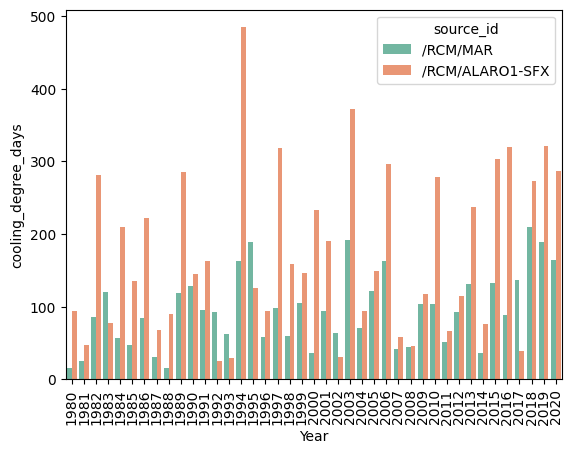

In [103]:
df["time"] = df["time"].dt.year
sns.barplot(data=df,x="time",y="cooling_degree_days", hue="source_id", palette="Set2")
# #Make the x axis only the year 

plt.xticks(rotation=90)

plt.xlabel("Year")